In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
from glob import glob
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

FOLDER = 'data/rasters'

In [2]:
# Load all mean rasters into a single DataFrame
mean_files = sorted([f for f in glob(f'{FOLDER}/*.tif') if '_se' not in os.path.basename(f)])

# Read the first raster to get coordinates and metadata
with rasterio.open(mean_files[0]) as src:
    transform = src.transform
    crs = src.crs
    nodata = src.nodata
    height, width = src.shape

# Generate lon/lat for every pixel center
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
lons, lats = rasterio.transform.xy(transform, rows, cols)
lons = np.array(lons).flatten()
lats = np.array(lats).flatten()

# Load all arrays
data_dict = {'lon': lons, 'lat': lats}
for file in mean_files:
    with rasterio.open(file) as src:
        arr = src.read(1).flatten()
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
    prop_depth = os.path.basename(file).replace('.tif', '')
    data_dict[prop_depth] = arr

df = pd.DataFrame(data_dict)

# Drop pixels with any NaN (outside Sri Lanka mask)
df = df.dropna().reset_index(drop=True)

print(f"Total valid pixels (whole Sri Lanka): {len(df):,}")
df.head()

Total valid pixels (whole Sri Lanka): 60,847


,lon,lat,bd_0-5cm,bd_15-30cm,bd_30-60cm,bd_5-15cm,bd_60-100cm,cec_0-5cm,cec_15-30cm,cec_30-60cm,...,vmc15_0-5cm,vmc15_15-30cm,vmc15_30-60cm,vmc15_5-15cm,vmc15_60-100cm,vmc33_0-5cm,vmc33_15-30cm,vmc33_30-60cm,vmc33_5-15cm,vmc33_60-100cm
0,80.200606,9.831007,1.474551,1.251214,1.247321,1.268088,1.267176,9.696836,10.050234,8.765096,...,0.091413,0.094432,0.086927,0.089380,0.113287,0.139779,0.141806,0.140917,0.136302,0.164341
1,80.210034,9.831007,1.477457,1.254274,1.248992,1.271305,1.267237,9.696094,10.049469,8.764836,...,0.090660,0.093527,0.086824,0.088607,0.113083,0.138718,0.140517,0.140769,0.135216,0.164066
2,80.219462,9.831007,1.480309,1.257274,1.250630,1.274452,1.267298,9.695372,10.048725,8.764590,...,0.089930,0.092652,0.086723,0.087860,0.112884,0.137684,0.139267,0.140626,0.134159,0.163800
3,80.040334,9.821579,1.448169,1.197490,1.218059,1.210042,1.266133,9.706892,10.061332,8.765575,...,0.106922,0.113572,0.088722,0.105516,0.117233,0.161814,0.169483,0.143784,0.159180,0.169806
4,80.144039,9.821579,1.456341,1.232489,1.237070,1.248343,1.266806,9.701566,10.055047,8.766954,...,0.095993,0.100113,0.087610,0.094113,0.114533,0.146450,0.150088,0.141942,0.143163,0.166092


In [3]:
# Crop to Western Province (Districts = Colombo + Kalutara + Gampaha)
districts = gpd.read_file('data/boundaries/gadm41_LKA_1.json')

# Select the three Western Province districts
western_districts = districts[districts['NAME_1'].isin(['Colombo', 'Gampaha', 'Kalutara'])].copy()

# Dissolve into single Western Province polygon
western_province = western_districts.dissolve()

# Create GeoDataFrame of pixels
geometry = [Point(xy) for xy in zip(df.lon, df.lat)]
pixels_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

# Spatial join – keep only pixels inside the three Western districts
western_pixels = pixels_gdf.sjoin(western_province, how='inner', predicate='within')

df_western = western_pixels.drop(columns=['geometry', 'index_right']).reset_index(drop=True)

print(f"Pixels in Western Province: {len(df_western):,}")
df = df_western.copy()
df.head()

Pixels in Western Province: 3,422


,lon,lat,bd_0-5cm,bd_15-30cm,bd_30-60cm,bd_5-15cm,bd_60-100cm,cec_0-5cm,cec_15-30cm,cec_30-60cm,...,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1
0,80.125184,7.323213,1.557927,1.442331,1.439978,1.415508,1.345131,15.267301,16.852371,15.398573,...,LKA,SriLanka,Colombo,NA,NA,Distrikkaya,District,NA,LK.CO,NA
1,80.134612,7.323213,1.558571,1.440546,1.438355,1.412790,1.345062,15.265265,16.851543,15.398051,...,LKA,SriLanka,Colombo,NA,NA,Distrikkaya,District,NA,LK.CO,NA
2,80.002622,7.313786,1.543519,1.542667,1.551212,1.527530,1.348263,15.189331,16.596306,14.792064,...,LKA,SriLanka,Colombo,NA,NA,Distrikkaya,District,NA,LK.CO,NA
3,80.012050,7.313786,1.543147,1.543052,1.551626,1.527253,1.348302,15.187772,16.595743,14.791530,...,LKA,SriLanka,Colombo,NA,NA,Distrikkaya,District,NA,LK.CO,NA
4,80.021478,7.313786,1.542923,1.543448,1.552039,1.527009,1.348340,15.186189,16.595175,14.790990,...,LKA,SriLanka,Colombo,NA,NA,Distrikkaya,District,NA,LK.CO,NA


In [6]:
# Compute features
depths = ['0-5cm', '5-15cm', '15-30cm', '30-60cm', '60-100cm']
thicknesses_cm = [5, 10, 15, 30, 40]
thicknesses_mm = [t * 10 for t in thicknesses_cm]  # for water depth calculation


# Helper to get columns for a property
def get_cols(prop):
    return [f'{prop}_{d}' for d in depths if f'{prop}_{d}' in df.columns]


# Total Plant-Available Water Capacity (mm)
fc_cols = get_cols('vmc33')
wp_cols = get_cols('vmc15')

awc_per_layer = []
for i in range(5):
    awc_layer = (df[fc_cols[i]] - df[wp_cols[i]]) * thicknesses_mm[i]
    awc_per_layer.append(awc_layer)

df['WHC_total_mm'] = sum(awc_per_layer)
df['WHC_vol_avg'] = df[get_cols('vmc33')].mean(axis=1) - df[get_cols('vmc15')].mean(axis=1)


# Weighted averages for other properties
def weighted_avg(prop):
    cols = get_cols(prop)
    values = [df[c] * thicknesses_cm[i] for i, c in enumerate(cols)]
    return sum(values) / sum(thicknesses_cm)


df['organic_carbon_avg'] = weighted_avg('oc')
df['CEC_avg'] = weighted_avg('cec')
df['pH_avg'] = weighted_avg('ph')
df['bulk_density_avg'] = weighted_avg('bd')

# USDA texture class from weighted average percentages
clay_cols = get_cols('clay')
sand_cols = get_cols('sand')
silt_cols = get_cols('silt')

df['clay_avg'] = sum(df[c] * thicknesses_cm[i] for i, c in enumerate(clay_cols)) / 100
df['sand_avg'] = sum(df[c] * thicknesses_cm[i] for i, c in enumerate(sand_cols)) / 100
df['silt_avg'] = 100 - df['clay_avg'] - df['sand_avg']


def usda_texture(clay, sand, silt):
    if silt + clay == 100:
        return 'Clay'
    elif silt < 15 and clay < 10:
        return 'Sand'
    elif silt < 30 and clay < 10:
        return 'Loamy Sand'
    elif clay >= 40 and sand <= 45 and silt <= 60:
        return 'Clay'
    elif clay >= 35 and sand < 45:
        return 'Clay'
    elif clay >= 27 and clay < 40 and sand <= 20:
        return 'Silty Clay'
    elif clay >= 20 and clay < 35 and silt >= 80:
        return 'Silty Clay Loam'
    elif clay < 28 and silt >= 50 and silt < 80:
        return 'Silt Loam'
    elif clay < 28 and silt < 50 and sand > 52:
        return 'Sandy Loam'
    else:
        return 'Loam'


df['texture_class'] = df.apply(lambda row: usda_texture(row.clay_avg, row.sand_avg, row.silt_avg), axis=1)

# Composite fertility score
df['fertility_score'] = (0.4 * df['organic_carbon_avg'] +
                         0.3 * df['CEC_avg'] +
                         0.3 * (7 - abs(df['pH_avg'] - 7)))

# Final feature set
final_features = ['WHC_total_mm', 'organic_carbon_avg', 'CEC_avg', 'pH_avg', 'bulk_density_avg', 'texture_class',
                  'fertility_score']

df_final = df[['lon', 'lat'] + final_features].copy()
df_final.to_csv('output\wp.csv', index=False)
df_final.head()

,lon,lat,WHC_total_mm,organic_carbon_avg,CEC_avg,pH_avg,bulk_density_avg,texture_class,fertility_score
0,80.125184,7.323213,49.896774,1.703228,13.620208,5.520106,1.405843,Sandy Loam,6.423386
1,80.134612,7.323213,50.224106,1.696093,13.653935,5.522413,1.404821,Sandy Loam,6.431342
2,80.002622,7.313786,39.999668,1.927928,12.678790,5.458689,1.465998,Sandy Loam,6.212415
3,80.012050,7.313786,40.171951,1.925457,12.699521,5.459501,1.466149,Sandy Loam,6.217890
4,80.021478,7.313786,40.345760,1.922836,12.720733,5.460423,1.466312,Sandy Loam,6.223482


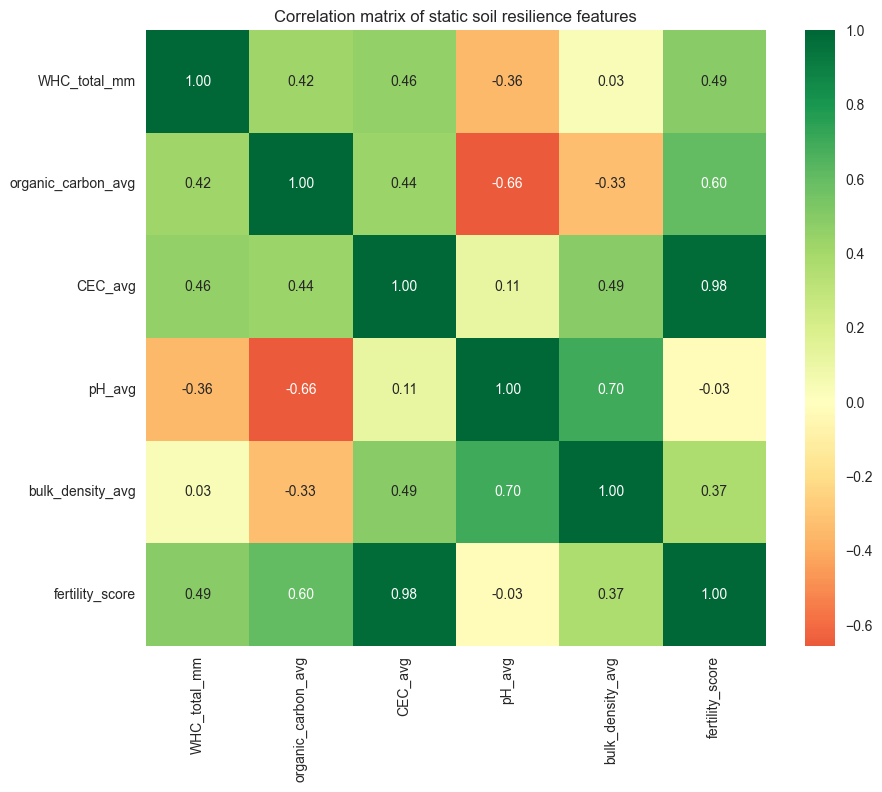

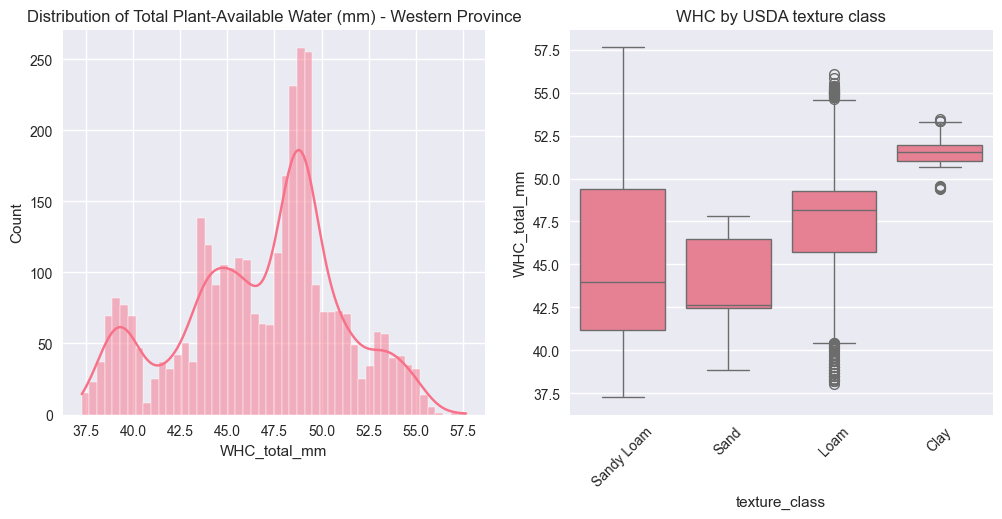

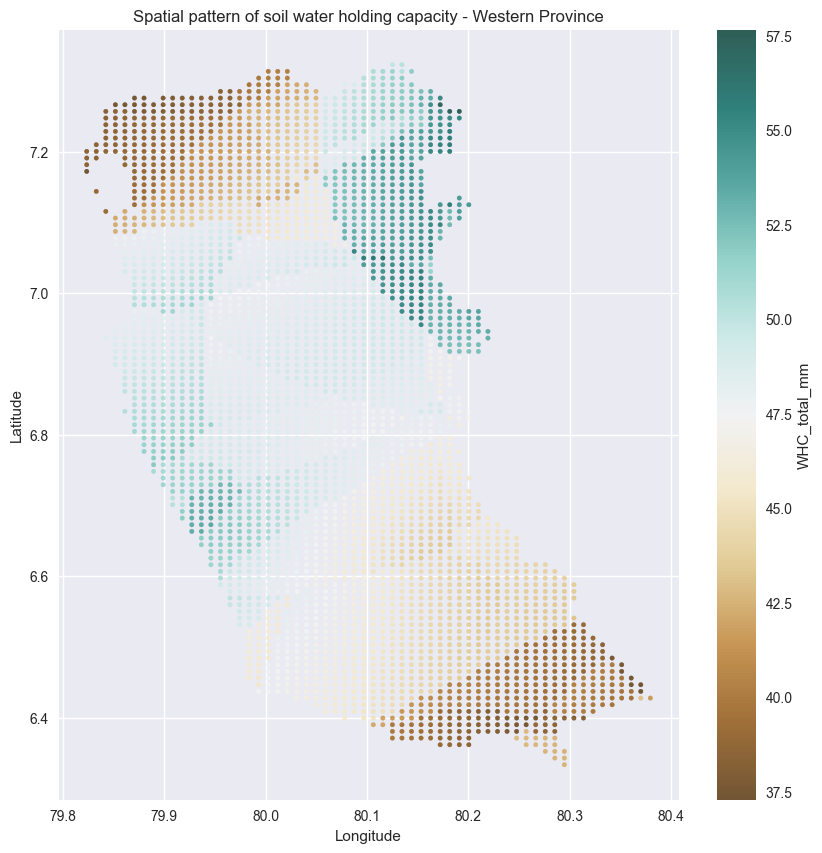

In [7]:
# Exploratory Data Analysis
df_final[final_features].describe().round(3)

# Correlation matrix (excluding categorical)
numeric_feats = [c for c in final_features if c != 'texture_class']
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[numeric_feats].corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Correlation matrix of static soil resilience features')
plt.show()

# Distribution of most important feature
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_final['WHC_total_mm'], kde=True, bins=50)
plt.title('Distribution of Total Plant-Available Water (mm) - Western Province')

plt.subplot(1, 2, 2)
sns.boxplot(x='texture_class', y='WHC_total_mm', data=df_final)
plt.xticks(rotation=45)
plt.title('WHC by USDA texture class')
plt.show()

# Spatial map
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
scatter = plt.scatter(df_final['lon'], df_final['lat'], c=df_final['WHC_total_mm'],
                      cmap='BrBG', s=10, alpha=0.8)
plt.colorbar(scatter, label='WHC_total_mm')
plt.title('Spatial pattern of soil water holding capacity - Western Province')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()